# checagem do pos-processamento - spacenet 2 aoi_3 paris

esse notebook roda o modelo num tile real e confere cada etapa do
pos-processamento separadamente: array de entrada, mapa de probabilidade,
limiarizacao, morfologia, contornos, e o geojson final comparado com o
gabarito original do tile.

In [1]:
import os
import sys
import json
import numpy as np
import rasterio
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../scripts'))

os.environ.setdefault('TF_USE_LEGACY_KERAS', '1')
os.environ.setdefault('SM_FRAMEWORK', 'tf.keras')

from dataset import normalize_percentile, discover_tiles
from postprocess import (
    load_model, predict_full_tile, apply_morphology,
    mask_to_polygons, pixel_to_geo,
)

# troque pro caminho do dataset na sua maquina
DATA_DIR = '../data'
MODEL_PATH = '../artefatos/best_model_tiling.keras'
TILE_ID = '786'  # None = pega o primeiro tile com predio; ou fixa um id tipo '652'

I0000 00:00:1783003306.697367   22839 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Segmentation Models: using `tf.keras` framework.


## 1. le o array de entrada

pega um tile real (RGB-PanSharpen), normaliza (percentil 2-98) e mostra a
imagem que vai entrar no modelo. essa e a array "crua" que a rede recebe.

tile escolhido: img786
tif: ../data/train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img786.tif
geojson: ../data/train/geojson/buildings/buildings_AOI_3_Paris_img786.geojson
shape do array cru: (650, 650, 3), dtype: uint16, min/max: 1/1711
shape apos normalizacao: (650, 650, 3), min/max: 0.000/1.000


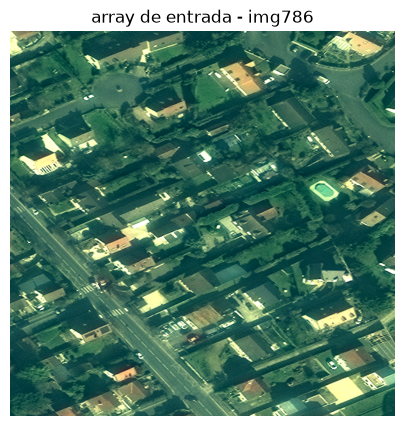

In [2]:
tiles = discover_tiles(DATA_DIR)

if TILE_ID is not None:
    tile = next(t for t in tiles if t['image_id'] == TILE_ID)
else:
    # pega o primeiro tile com pelo menos 1 predio no geojson
    import geopandas as gpd
    tile = None
    for t in tiles:
        gdf = gpd.read_file(t['geojson_path'])
        if len(gdf) > 0:
            tile = t
            break

print(f"tile escolhido: img{tile['image_id']}")
print(f"tif: {tile['image_path']}")
print(f"geojson: {tile['geojson_path']}")

with rasterio.open(tile['image_path']) as src:
    raw = src.read([1, 2, 3])
    raw = np.transpose(raw, (1, 2, 0))
    transform = src.transform
    crs = src.crs

print(f'shape do array cru: {raw.shape}, dtype: {raw.dtype}, min/max: {raw.min()}/{raw.max()}')

image = normalize_percentile(raw)
print(f'shape apos normalizacao: {image.shape}, min/max: {image.min():.3f}/{image.max():.3f}')

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(f"array de entrada - img{tile['image_id']}")
plt.axis('off')
plt.show()

## 2. roda o modelo - mapa de probabilidade

carrega o modelo treinado e roda inferencia no tile inteiro (tiling). a
saida e um array (H, W) com valores continuos entre 0 e 1 - a probabilidade
de cada pixel ser predio, ainda sem nenhuma decisao binaria.

I0000 00:00:1783003311.486347   22839 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5590 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:07:00.0, compute capability: 8.6


modelo carregado de: ../artefatos/best_model_tiling.keras


I0000 00:00:1783003316.590918   22928 cuda_dnn.cc:461] Loaded cuDNN version 92302


shape do mapa de probabilidade: (650, 650)
min/max: 0.000/1.000


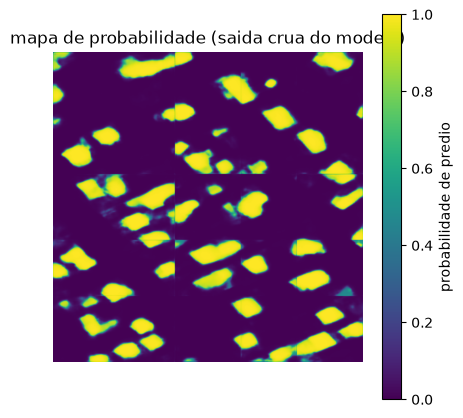

In [3]:
model = load_model(MODEL_PATH, backbone='resnet34')
prob_map = predict_full_tile(model, image, mode='tiling', patch_size=256)

print(f'shape do mapa de probabilidade: {prob_map.shape}')
print(f'min/max: {prob_map.min():.3f}/{prob_map.max():.3f}')

plt.figure(figsize=(5, 5))
plt.imshow(prob_map, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='probabilidade de predio')
plt.title('mapa de probabilidade (saida crua do modelo)')
plt.axis('off')
plt.show()

## 3. limiarizacao

corta o mapa de probabilidade num limiar fixo (0.5): acima vira predio (255),
abaixo vira fundo (0). e a primeira decisao binaria da pipeline.

pixels de predio antes da morfologia: 78063


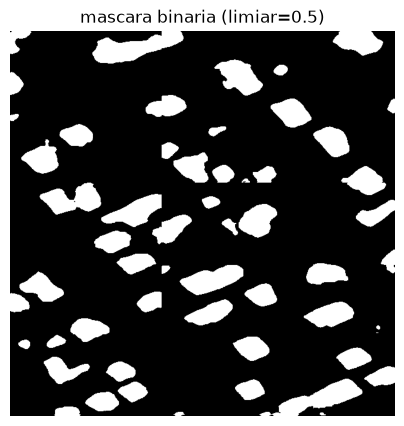

In [4]:
threshold = 0.5
binary = (prob_map > threshold).astype(np.uint8) * 255

print(f'pixels de predio antes da morfologia: {(binary > 0).sum()}')

plt.figure(figsize=(5, 5))
plt.imshow(binary, cmap='gray')
plt.title(f'mascara binaria (limiar={threshold})')
plt.axis('off')
plt.show()

## 4. morfologia

aplica abertura (remove ruido/pontinhos soltos) e depois fechamento (preenche
buraquinhos) na mascara binaria. compara antes e depois lado a lado.

pixels de predio antes: 78063
pixels de predio depois: 77898


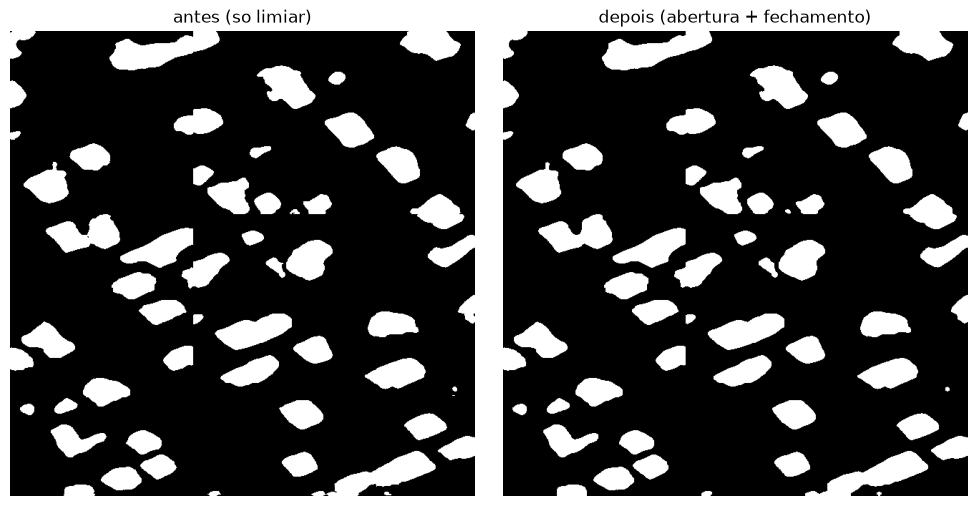

In [5]:
cleaned = apply_morphology(binary, kernel_size=5)

print(f'pixels de predio antes: {(binary > 0).sum()}')
print(f'pixels de predio depois: {(cleaned > 0).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(binary, cmap='gray')
axes[0].set_title('antes (so limiar)')
axes[0].axis('off')
axes[1].imshow(cleaned, cmap='gray')
axes[1].set_title('depois (abertura + fechamento)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 5. extracao de contornos

usa `cv2.findContours` pra achar a borda de cada mancha da mascara limpa,
separando os predios um do outro. cada contorno vira um poligono (ainda em
coordenada de pixel, ainda serrilhado).

contornos encontrados: 55


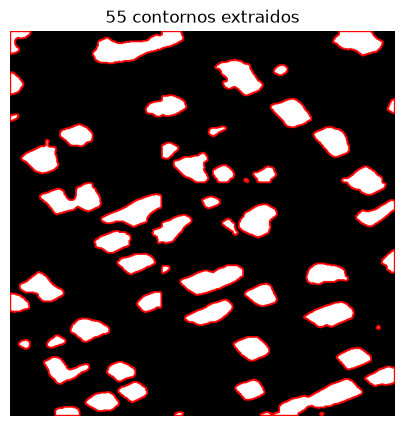

In [6]:
import cv2

contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f'contornos encontrados: {len(contours)}')

vis = np.stack([cleaned] * 3, axis=-1).copy()
cv2.drawContours(vis, contours, -1, (255, 0, 0), 2)

plt.figure(figsize=(5, 5))
plt.imshow(vis)
plt.title(f'{len(contours)} contornos extraidos')
plt.axis('off')
plt.show()

## 6. poligono final e comparacao geojson

aplica a simplificacao (douglas-peucker), filtra por area minima, converte
pra coordenadas geograficas (lat/lon) via transformada afim do `.tif`, e
gera o geojson novo. compara lado a lado com o geojson original (gabarito)
desse mesmo tile.

In [7]:
pixel_polygons = mask_to_polygons(prob_map, threshold=threshold, min_area=100, morph_kernel=5)
print(f'poligonos apos simplificacao + filtro de area: {len(pixel_polygons)}')

geo_polygons = [pixel_to_geo(p, transform) for p in pixel_polygons]

geojson_novo = {
    'type': 'FeatureCollection',
    'features': [
        {'type': 'Feature', 'geometry': p.__geo_interface__, 'properties': {}}
        for p in geo_polygons
    ],
}

with open(tile['geojson_path']) as f:
    geojson_original = json.load(f)

print(f"predios no gabarito original: {len(geojson_original['features'])}")
print(f'predios no geojson gerado: {len(geojson_novo["features"])}')

poligonos apos simplificacao + filtro de area: 51
predios no gabarito original: 58
predios no geojson gerado: 51


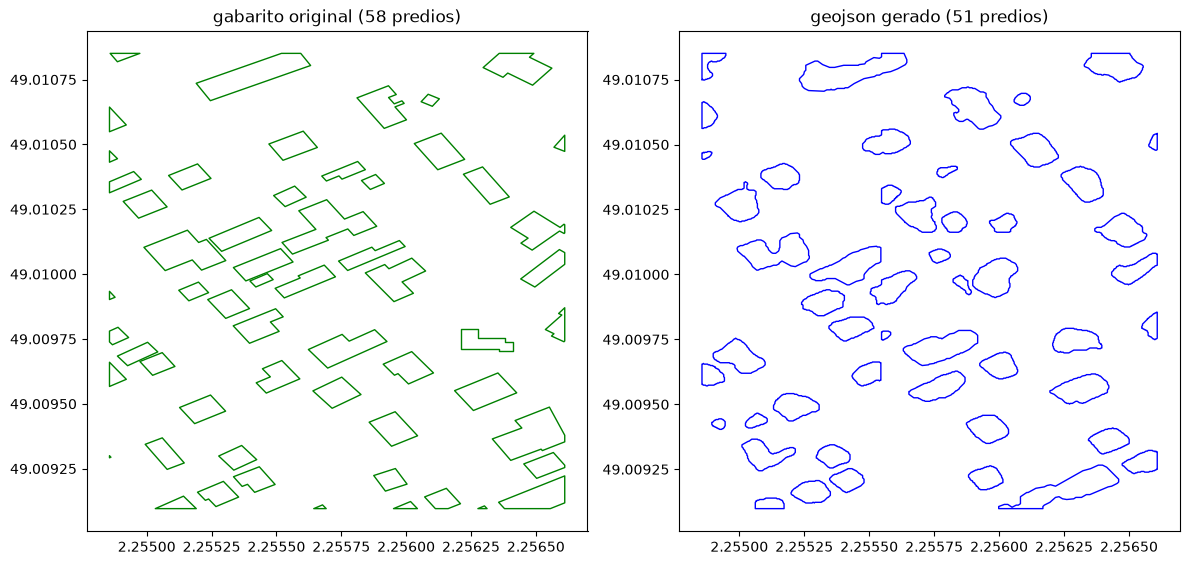

In [8]:
import geopandas as gpd

gdf_original = gpd.read_file(tile['geojson_path'])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

gdf_original.plot(ax=axes[0], color='none', edgecolor='green', linewidth=1)
axes[0].set_title(f'gabarito original ({len(gdf_original)} predios)')
axes[0].set_aspect('equal')

if len(geo_polygons) > 0:
    gdf_novo = gpd.GeoDataFrame(geometry=geo_polygons, crs='EPSG:4326')
    gdf_novo.plot(ax=axes[1], color='none', edgecolor='blue', linewidth=1)
else:
    axes[1].text(0.5, 0.5, 'nenhum predio detectado', ha='center', va='center')
axes[1].set_title(f'geojson gerado ({len(geo_polygons)} predios)')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()